# E-commerce Sales & Customer Behaviour Analysis

## 1. Project Overview

This project analyses transactional data from a UK-based online retailer to understand sales performance, customer purchasing behaviour, product performance, cancellations, geographic trends, and customer value.

The project uses Python for data cleaning and exploratory analysis, MySQL for advanced SQL analysis, and Power BI for interactive business intelligence reporting.

## 2. Initial Data Inspection

Before cleaning or analysing the dataset, the raw data is inspected to understand its structure, dimensions, columns, data types, missing values, and potential data-quality issues.

## %pip install openpyxl

This will help to open the excel sheet

In [1]:
## import pandas

import pandas as pd

In [2]:
import os

print(os.getcwd())

C:\Users\Owner\Desktop\MyDataScience_Project\Ecommerce Sales Customer Analysis\python


In [3]:
print(os.listdir())

['.ipynb_checkpoints', 'ecommerce_sales_customer_analysis.ipynb']


In [4]:
print(os.listdir(".."))

['.ipynb_checkpoints', '.~lock.Online Retail - Copy.xlsx#', 'data', 'python', 'sql']


In [5]:
df = pd.read_excel("../data/online_retail.xlsx")

In [6]:
df.shape

(541909, 8)

In [7]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [8]:
df.tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,2011-12-09 12:50:00,3.75,12680.0,France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-12-09 12:50:00,1.95,12680.0,France
541902,581587,22629,SPACEBOY LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680.0,France
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,12680.0,France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [9]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [11]:
## Check missing values

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
## Check duplicate rows

df.duplicated().sum()

np.int64(5268)

In [13]:
## inspect the numerical columns without changing anything

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## Step 3 — Data Quality Assessment

In [14]:
# Step 3.1 — Investigate cancellations and negative quantities
# In this dataset, invoice numbers beginning with C can represent cancellations. Let's verify what they look like in our actual data.

cancelled = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
]

cancelled.shape

(9288, 8)

In [15]:
cancelled.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [16]:
cancelled.tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540141,C581468,21314,SMALL GLASS HEART TRINKET POT,-10,2011-12-08 19:26:00,2.10,13599.0,United Kingdom
540142,C581468,22098,BOUDOIR SQUARE TISSUE BOX,-12,2011-12-08 19:26:00,0.39,13599.0,United Kingdom
540176,C581470,23084,RABBIT NIGHT LIGHT,-4,2011-12-08 19:28:00,2.08,17924.0,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom
540448,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,-12,2011-12-09 09:57:00,1.95,14397.0,United Kingdom
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom
541717,C581569,20979,36 PENCILS TUBE RED RETROSPOT,-5,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [17]:
cancelled["Quantity"].describe()

count     9288.000000
mean       -29.885228
std       1145.786965
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

In [18]:
cancelled["Quantity"].ge(0).sum()

np.int64(0)

In [19]:
# Step 3.2 — Negative quantities outside cancellations

negative_non_cancelled = df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]

negative_non_cancelled.shape

(1336, 8)

In [20]:
negative_non_cancelled.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [21]:
negative_non_cancelled.tail(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
524369,580546,23406,CHECK,-21,2011-12-05 09:27:00,0.0,NaN,United Kingdom
524370,580547,21201,???,-390,2011-12-05 09:29:00,0.0,NaN,United Kingdom
524472,580561,22043,dotcom,-9,2011-12-05 10:25:00,0.0,NaN,United Kingdom
532723,580990,21109,wet,-48,2011-12-06 16:54:00,0.0,NaN,United Kingdom
532724,580991,22481,wet boxes,-288,2011-12-06 16:55:00,0.0,NaN,United Kingdom
535134,581190,84801A,check,-102,2011-12-07 16:55:00,0.0,NaN,United Kingdom
535321,581198,22025,check,-30,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535323,581200,84508C,check,-21,2011-12-07 18:27:00,0.0,NaN,United Kingdom
535324,581201,22217,damages?,-155,2011-12-07 18:30:00,0.0,NaN,United Kingdom


In [22]:
negative_non_cancelled["Quantity"].describe()

count    1336.000000
mean     -154.907934
std       588.292456
min     -9600.000000
25%       -84.000000
50%       -30.000000
75%        -8.000000
max        -1.000000
Name: Quantity, dtype: float64

### This distinction will be important later:

### C invoice + negative quantity → customer cancellation/return-type transaction

### Non-C invoice + negative quantity → often operational/inventory adjustment in this dataset

In [23]:
# Step 3.3 — Investigate zero and negative UnitPrice

negative_price = df[df["UnitPrice"] < 0]

negative_price.shape

(2, 8)

In [24]:
negative_price

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [25]:
zero_price = df[df["UnitPrice"] == 0]

zero_price.shape

(2515, 8)

In [26]:
zero_price.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [27]:
zero_price.tail(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
535323,581200,84508C,check,-21,2011-12-07 18:27:00,0.0,NaN,United Kingdom
535324,581201,22217,damages?,-155,2011-12-07 18:30:00,0.0,NaN,United Kingdom
535325,581202,23404,check,41,2011-12-07 18:30:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535327,581204,85104,????damages????,-355,2011-12-07 18:32:00,0.0,NaN,United Kingdom
535328,581205,20893,damages,-55,2011-12-07 18:32:00,0.0,NaN,United Kingdom
535329,581206,21693,mixed up,-87,2011-12-07 18:34:00,0.0,NaN,United Kingdom
535330,581207,21688,mixed up,-337,2011-12-07 18:34:00,0.0,NaN,United Kingdom
535331,581208,72801C,check,-10,2011-12-07 18:35:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom


### Step 3.4 — Investigate missing CustomerID

   ### This is our biggest missing-data issue:

In [28]:
missing_customer = df[df["CustomerID"].isna()]

missing_customer.shape

(135080, 8)

In [29]:
missing_customer.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom


In [30]:
missing_customer.tail(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541521,581498,84032A,CHARLIE+LOLA PINK HOT WATER BOTTLE,4,2011-12-09 10:26:00,5.79,NaN,United Kingdom
541522,581498,84032B,CHARLIE + LOLA RED HOT WATER BOTTLE,3,2011-12-09 10:26:00,3.29,NaN,United Kingdom
541523,581498,84375,SET OF 20 KIDS COOKIE CUTTERS,3,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541524,581498,84509a,SET OF 4 ENGLISH ROSE PLACEMATS,1,2011-12-09 10:26:00,7.46,NaN,United Kingdom
541525,581498,84558a,3D DOG PICTURE PLAYING CARDS,1,2011-12-09 10:26:00,5.79,NaN,United Kingdom
541526,581498,84832,ZINC WILLIE WINKIE CANDLE STICK,26,2011-12-09 10:26:00,1.63,NaN,United Kingdom
541527,581498,84968e,SET OF 16 VINTAGE BLACK CUTLERY,1,2011-12-09 10:26:00,24.96,NaN,United Kingdom
541528,581498,84970s,HANGING HEART ZINC T-LIGHT HOLDER,1,2011-12-09 10:26:00,2.08,NaN,United Kingdom
541529,581498,84997a,CHILDRENS CUTLERY POLKADOT GREEN,2,2011-12-09 10:26:00,8.29,NaN,United Kingdom
541530,581498,84997b,CHILDRENS CUTLERY RETROSPOT RED,3,2011-12-09 10:26:00,8.29,NaN,United Kingdom


In [31]:
missing_customer[
    (missing_customer["Quantity"] > 0) &
    (missing_customer["UnitPrice"] > 0)
].shape

(132220, 8)

### Step 3.4 — What was discovered

I have 135,080 rows with missing CustomerID, but 132,220 of those rows have both positive quantity and positive price.

That means most missing-customer records are not obviously bad data. Many look like genuine sales transactions. For example, invoice 536544 contains normal products, positive quantities and positive prices; it simply does not identify the customer.

So I should not delete all missing CustomerID rows from the master sales dataset.

Instead, later I will use two analytical views:

Sales/product analysis: transactions can remain even when CustomerID is missing, provided they meet my valid-sales criteria.
Customer behaviour/RFM analysis: I will require a valid CustomerID, because I cannot calculate repeat purchases, recency, frequency, or customer value for an unidentified customer.

That's a more defensible portfolio approach than blindly using dropna()

In [32]:
# Step 3.5 — Investigate missing Description
# This one is much smaller:

missing_description = df[df["Description"].isna()]

missing_description.shape

(1454, 8)

In [33]:
missing_description.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [34]:
missing_description.tail(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
511451,579500,22810,NaN,33,2011-11-29 16:14:00,0.0,NaN,United Kingdom
514205,579688,21116,NaN,-33,2011-11-30 13:51:00,0.0,NaN,United Kingdom
514287,579691,47503A,NaN,-5,2011-11-30 14:05:00,0.0,NaN,United Kingdom
514651,579738,21927,NaN,8,2011-11-30 14:26:00,0.0,NaN,United Kingdom
516189,579880,22947,NaN,5,2011-11-30 17:14:00,0.0,NaN,United Kingdom
517719,580087,84341B,NaN,-2,2011-12-01 14:27:00,0.0,NaN,United Kingdom
519967,580197,22696,NaN,6,2011-12-02 12:04:00,0.0,NaN,United Kingdom
521333,580359,20775,NaN,-35,2011-12-02 16:11:00,0.0,NaN,United Kingdom
522160,580379,72225C,NaN,-144,2011-12-02 17:57:00,0.0,NaN,United Kingdom
522162,580381,21758,NaN,-9,2011-12-02 17:58:00,0.0,NaN,United Kingdom


In [35]:
# let's check whether these rows have a positive price

missing_description["UnitPrice"].value_counts().head(10)

UnitPrice
0.0    1454
Name: count, dtype: int64

In [36]:
missing_description["CustomerID"].notna().sum()

np.int64(0)

In [37]:
# Step 3.6 — Investigate the 5,268 duplicates
# Now let's understand the duplicate records before deciding whether they should be removed.

# First, display some duplicated rows together:

duplicates = df[df.duplicated(keep=False)]

duplicates.shape

(10147, 8)

In [38]:
duplicates.sort_values(
    ["InvoiceNo", "StockCode", "InvoiceDate"]
).head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [39]:
# And finally, let's determine how many rows would actually be removed if I kept the first occurrence:

df.duplicated().sum()

np.int64(5268)

In [40]:
# Step 3.6 — What the results mean
# shows all copies involved in duplication, including the first/original occurrence.

df[df.duplicated(keep=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [41]:
# counts only the additional identical copies after the first occurrence.

df.duplicated().sum()

np.int64(5268)

In [42]:
# remove exact duplicate rows

df = df.drop_duplicates()

### Step 3.7 — Final quality check: cancellation structure

Before we finish the assessment phase, I want to check one more relationship.

We know:

9,288 rows have invoice numbers beginning with C

all 9,288 have negative quantities

another 1,336 negative-quantity rows don't begin with C

Now let's see the overall negative-quantity count.

In [43]:
(df["Quantity"] < 0).sum()

np.int64(10587)

In [44]:
(df["Quantity"] == 0).sum()

np.int64(0)

## 4. Data Cleaning

Following the data quality assessment, the dataset is cleaned using business-aware rules. The original dataframe is preserved, while separate analytical datasets will be created for sales, cancellations, and customer-level analysis.

In [45]:
df_clean = df.copy()

df_clean.shape

(536641, 8)

In [46]:
# remove only exact duplicates

df_clean = df_clean.drop_duplicates()

df_clean.shape

(536641, 8)

In [47]:
df_clean.duplicated().sum()

np.int64(0)

#### Step 4.2 — Create the Valid Sales Dataset

Now we're going to create a dataset specifically for sales analysis.

A valid sale should have:

Quantity > 0

UnitPrice > 0

Invoice does not begin with C

Notice that we are not requiring CustomerID yet. That's intentional: unidentified customers can still contribute valid revenue and product sales.

In [48]:
sales_df = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0) &
    (~df_clean["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

sales_df.shape

(524878, 8)

In [49]:
print("Rows:", len(sales_df))
print("Negative quantities:", (sales_df["Quantity"] < 0).sum())
print("Zero/negative prices:", (sales_df["UnitPrice"] <= 0).sum())
print(
    "Cancellation invoices:",
    sales_df["InvoiceNo"].astype(str).str.startswith("C").sum()
)

Rows: 524878
Negative quantities: 0
Zero/negative prices: 0
Cancellation invoices: 0


#### Step 4.3 — Create Revenue

At the moment we have Quantity and UnitPrice, but not the monetary value of each transaction line.

In [50]:
# create it

sales_df["Revenue"] = (
    sales_df["Quantity"] * sales_df["UnitPrice"]
)

In [51]:
# check it

sales_df[
    ["InvoiceNo", "Quantity", "UnitPrice", "Revenue"]
].head(10)

,InvoiceNo,Quantity,UnitPrice,Revenue
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34
5,536365,2,7.65,15.30
6,536365,6,4.25,25.50
7,536366,6,1.85,11.10
8,536366,6,1.85,11.10
9,536367,32,1.69,54.08


In [52]:
sales_df[
    ["InvoiceNo", "Quantity", "UnitPrice", "Revenue"]
].tail(10)

,InvoiceNo,Quantity,UnitPrice,Revenue
541899,581587,4,3.75,15.00
541900,581587,4,3.75,15.00
541901,581587,8,1.95,15.60
541902,581587,12,1.95,23.40
541903,581587,4,4.15,16.60
541904,581587,12,0.85,10.20
541905,581587,6,2.10,12.60
541906,581587,4,4.15,16.60
541907,581587,4,4.15,16.60
541908,581587,3,4.95,14.85


In [53]:
# calculate Total Revenue

sales_df["Revenue"].sum()

np.float64(10642110.804000001)

In [54]:
# verify the new column

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  object        
 8   Revenue      524878 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 40.0+ MB


#### Step 4.4 — Create the Customer Analysis Dataset

Now we'll create a second dataset specifically for customer behaviour.

This time, CustomerID must be present.

In [55]:
customer_df = sales_df[
    sales_df["CustomerID"].notna()
].copy()

customer_df.shape

(392692, 9)

In [56]:
customer_df["CustomerID"].isna().sum()

np.int64(0)

In [57]:
# let's find out how many unique identifiable customers we have

customer_df["CustomerID"].nunique()

4338

In [58]:
# an ID isn't really a numerical measurement, convert it to an integer

customer_df["CustomerID"] = customer_df["CustomerID"].astype("int64")

In [59]:
customer_df[["CustomerID"]].head()

,CustomerID
0,17850
1,17850
2,17850
3,17850
4,17850


#### Step 4.5 — Create a Separate Cancellation Dataset

We don't want to throw cancellations away. They are valuable business information, so we'll keep them separately from positive sales.

Create it from df_clean so we're working with the deduplicated data:

In [60]:
cancellations_df = df_clean[
    df_clean["InvoiceNo"].astype(str).str.startswith("C")
].copy()

cancellations_df.shape

(9251, 8)

In [61]:
print(
    "Cancellation rows:",
    len(cancellations_df)
)

print(
    "Non-negative quantities:",
    (cancellations_df["Quantity"] >= 0).sum()
)

Cancellation rows: 9251
Non-negative quantities: 0


In [62]:
# Create cancellation value

cancellations_df["CancellationValue"] = (
    cancellations_df["Quantity"].abs()
    * cancellations_df["UnitPrice"]
)

In [63]:
# inspect

cancellations_df[
    [
        "InvoiceNo",
        "Quantity",
        "UnitPrice",
        "CancellationValue"
    ]
].head(10)

,InvoiceNo,Quantity,UnitPrice,CancellationValue
141,C536379,-1,27.50,27.50
154,C536383,-1,4.65,4.65
235,C536391,-12,1.65,19.80
236,C536391,-24,0.29,6.96
237,C536391,-24,0.29,6.96
238,C536391,-24,0.29,6.96
239,C536391,-12,3.45,41.40
240,C536391,-12,1.65,19.80
241,C536391,-24,1.65,39.60
939,C536506,-6,4.25,25.50


In [64]:
cancellations_df["CancellationValue"].sum()

np.float64(893979.73)

In [65]:
(cancellations_df["Quantity"] >= 0).sum()

np.int64(0)

In [66]:
# Step 4.6 — Check the Date Range
# Before creating time-based features, let's verify the date range of our valid sales data.

sales_df["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [67]:
sales_df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [68]:
sales_df["InvoiceDate"].dtype

dtype('<M8[ns]')

### Step 4.7 — Create Time Features

Now let's create useful date columns from InvoiceDate. These will later make monthly sales analysis much easier in Python, SQL, and Power BI.

In [69]:
sales_df["Year"] = sales_df["InvoiceDate"].dt.year

sales_df["Month"] = sales_df["InvoiceDate"].dt.month

sales_df["MonthName"] = sales_df["InvoiceDate"].dt.month_name()

sales_df["YearMonth"] = sales_df["InvoiceDate"].dt.to_period("M")

In [70]:
sales_df[
    ["InvoiceDate", "Year", "Month", "MonthName", "YearMonth"]
].head(10)

,InvoiceDate,Year,Month,MonthName,YearMonth
0,2010-12-01 08:26:00,2010,12,December,2010-12
1,2010-12-01 08:26:00,2010,12,December,2010-12
2,2010-12-01 08:26:00,2010,12,December,2010-12
3,2010-12-01 08:26:00,2010,12,December,2010-12
4,2010-12-01 08:26:00,2010,12,December,2010-12
5,2010-12-01 08:26:00,2010,12,December,2010-12
6,2010-12-01 08:26:00,2010,12,December,2010-12
7,2010-12-01 08:28:00,2010,12,December,2010-12
8,2010-12-01 08:28:00,2010,12,December,2010-12
9,2010-12-01 08:34:00,2010,12,December,2010-12


In [71]:
# Check the years

sales_df["Year"].value_counts().sort_index()

Year
2010     40991
2011    483887
Name: count, dtype: int64

In [72]:
sales_df["YearMonth"].unique()

<PeriodArray>
['2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06',
 '2011-07', '2011-08', '2011-09', '2011-10', '2011-11', '2011-12']
Length: 13, dtype: period[M]

#### Step 4.8 — Final Validation of Our Cleaned Datasets

Before we leave data cleaning and begin EDA, let's make sure our three analytical datasets are consistent.

In [73]:
print("Clean master rows:", len(df_clean))
print("Sales rows:", len(sales_df))
print("Customer sales rows:", len(customer_df))
print("Cancellation rows:", len(cancellations_df))

Clean master rows: 536641
Sales rows: 524878
Customer sales rows: 392692
Cancellation rows: 9251


In [74]:
print("Sales revenue:", round(sales_df["Revenue"].sum(), 2))
print(
    "Cancellation value:",
    round(cancellations_df["CancellationValue"].sum(), 2)
)
print("Unique customers:", customer_df["CustomerID"].nunique())

Sales revenue: 10642110.8
Cancellation value: 893979.73
Unique customers: 4338


In [75]:
print("Sales duplicates:", sales_df.duplicated().sum())
print("Customer missing IDs:", customer_df["CustomerID"].isna().sum())
print("Sales negative quantities:", (sales_df["Quantity"] < 0).sum())
print("Sales non-positive prices:", (sales_df["UnitPrice"] <= 0).sum())

Sales duplicates: 0
Customer missing IDs: 0
Sales negative quantities: 0
Sales non-positive prices: 0


## 5. Exploratory Data Analysis

The cleaned datasets are analysed to evaluate overall sales performance, revenue trends, customer purchasing behaviour, product performance, geographic patterns, and cancellations.

In [76]:
# Step 5.1 — Overall Sales Performance
# calculate the first business KPIs.

total_revenue = sales_df["Revenue"].sum()

total_orders = sales_df["InvoiceNo"].nunique()

total_units = sales_df["Quantity"].sum()

unique_products = sales_df["StockCode"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Units Sold:", total_units)
print("Unique Products:", unique_products)

Total Revenue: 10642110.8
Total Orders: 19960
Total Units Sold: 5572420
Unique Products: 3922


In [77]:
# calculate Average Order Value (AOV)
# On average, how much gross positive-sales revenue does an order generate?

average_order_value = total_revenue / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 533.17


In [78]:
# Step 5.2 — Monthly Revenue Trend
# How does sales revenue change over time?

# First aggregate revenue by YearMonth:

monthly_revenue = (
    sales_df
    .groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,YearMonth,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


In [79]:
# Step 5.2 — Create the Monthly Revenue Chart
# Now let's visualise the trend.
# Because YearMonth is currently a Pandas Period, convert it to a string for straightforward plotting:

monthly_revenue["YearMonth"] = (
    monthly_revenue["YearMonth"].astype(str)
)

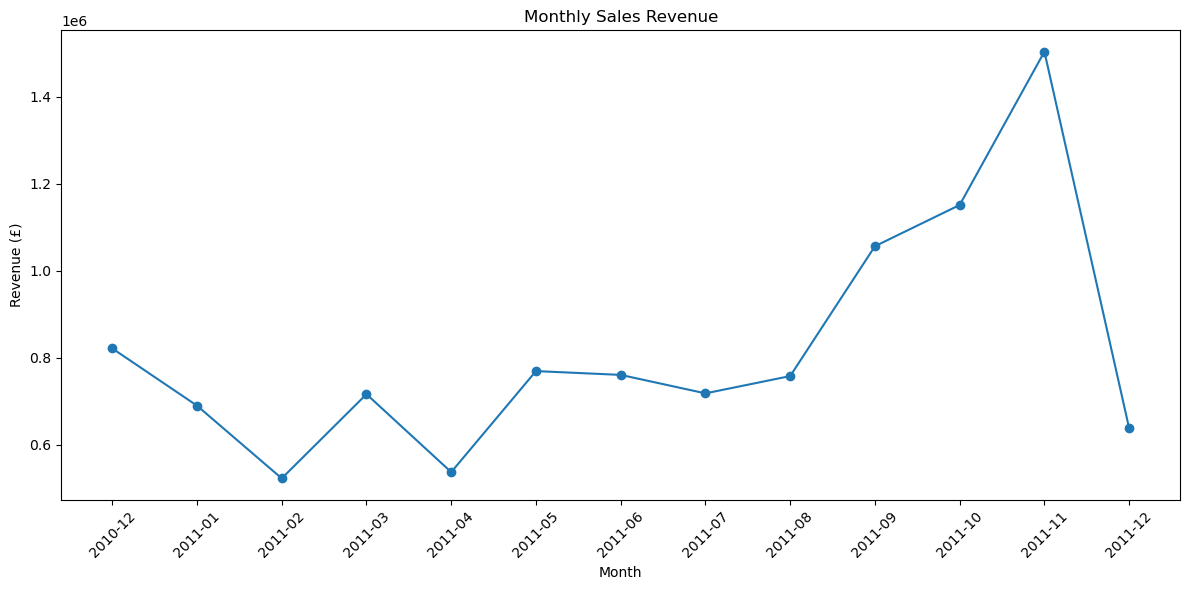

In [80]:
# create the line chart

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [81]:
# Step 5.3 — Monthly Order Volume
# Now let's find out whether the rise in revenue was also accompanied by more orders.

monthly_orders = (
    sales_df
    .groupby("YearMonth")["InvoiceNo"]
    .nunique()
    .reset_index(name="Orders")
)

monthly_orders

,YearMonth,Orders
0,2010-12,1559
1,2011-01,1086
2,2011-02,1100
3,2011-03,1454
4,2011-04,1246
5,2011-05,1681
6,2011-06,1533
7,2011-07,1475
8,2011-08,1361
9,2011-09,1837


In [82]:
# Step 5.3 — Create the Monthly Orders Chart
# First, convert YearMonth to a string:

monthly_orders["YearMonth"] = (
    monthly_orders["YearMonth"].astype(str)
)

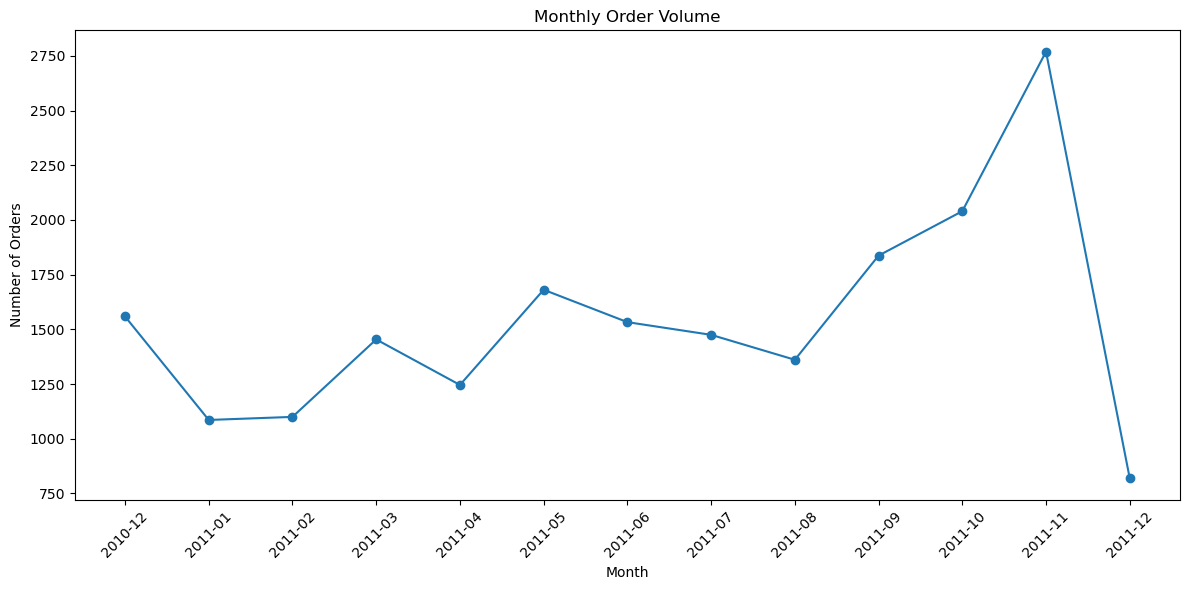

In [83]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_orders["YearMonth"],
    monthly_orders["Orders"],
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Step 5.4 — Monthly Average Order Value

Now we'll answer an important question:

Was revenue increasing simply because there were more orders, or were customers also spending more per order?

We already have monthly revenue and monthly orders. Let's combine them.

In [84]:
monthly_performance = monthly_revenue.merge(
    monthly_orders,
    on="YearMonth"
)

monthly_performance

,YearMonth,Revenue,Orders
0,2010-12,821452.730,1559
1,2011-01,689811.610,1086
2,2011-02,522545.560,1100
3,2011-03,716215.260,1454
4,2011-04,536968.491,1246
5,2011-05,769296.610,1681
6,2011-06,760547.010,1533
7,2011-07,718076.121,1475
8,2011-08,757841.380,1361
9,2011-09,1056435.192,1837


In [85]:
# calculate monthly AOV

monthly_performance["AverageOrderValue"] = (
    monthly_performance["Revenue"]
    / monthly_performance["Orders"]
)

monthly_performance["AverageOrderValue"] = (
    monthly_performance["AverageOrderValue"].round(2)
)

monthly_performance

,YearMonth,Revenue,Orders,AverageOrderValue
0,2010-12,821452.730,1559,526.91
1,2011-01,689811.610,1086,635.19
2,2011-02,522545.560,1100,475.04
3,2011-03,716215.260,1454,492.58
4,2011-04,536968.491,1246,430.95
5,2011-05,769296.610,1681,457.64
6,2011-06,760547.010,1533,496.12
7,2011-07,718076.121,1475,486.83
8,2011-08,757841.380,1361,556.83
9,2011-09,1056435.192,1837,575.09


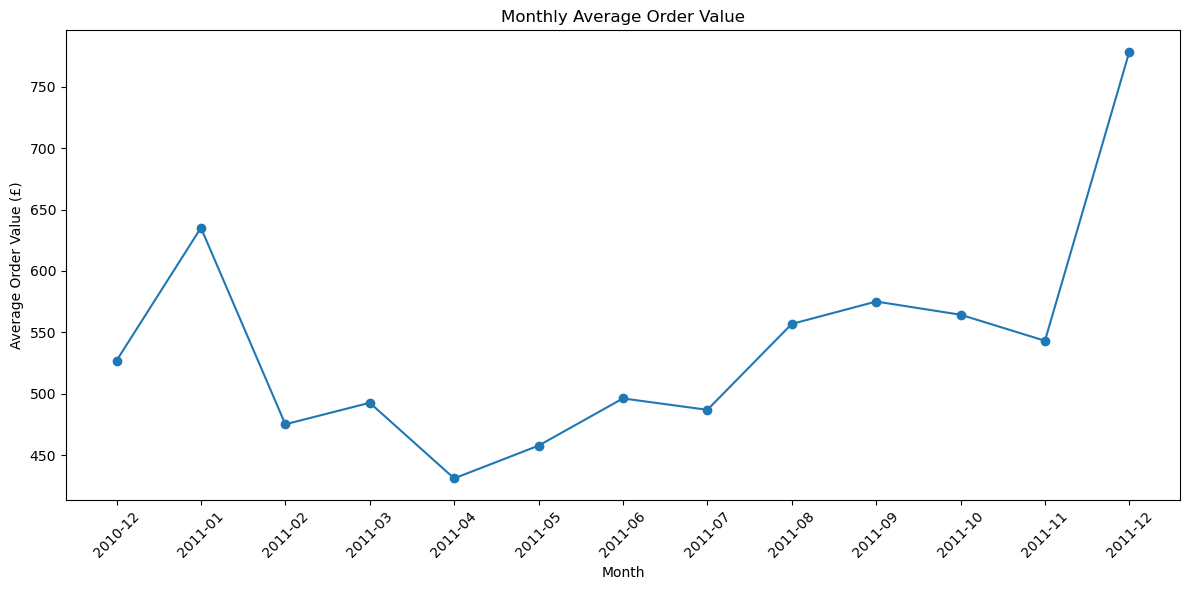

In [86]:
# Now create the Monthly AOV chart

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["YearMonth"],
    monthly_performance["AverageOrderValue"],
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Step 5.5 — Product Performance

Now we're moving from when customers bought to what they bought.

Our first question is:

Which products generated the most gross positive-sales revenue?

In [87]:
product_performance = (
    sales_df
    .groupby(["StockCode", "Description"])
    .agg(
        Revenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

product_performance.head()

,StockCode,Description,Revenue,UnitsSold,Orders
0,10002,INFLATABLE POLITICAL GLOBE,759.89,860,71
1,10080,GROOVY CACTUS INFLATABLE,119.09,303,22
2,10120,DOGGY RUBBER,40.32,192,29
3,10125,MINI FUNKY DESIGN TAPES,993.99,1295,91
4,10133,COLOURING PENCILS BROWN TUBE,1539.60,2856,196


In [88]:
# find the top 10 by revenue

top_products_revenue = (
    product_performance
    .sort_values("Revenue", ascending=False)
    .head(10)
    .copy()
)

top_products_revenue["Revenue"] = (
    top_products_revenue["Revenue"].round(2)
)

top_products_revenue

,StockCode,Description,Revenue,UnitsSold,Orders
4150,DOT,DOTCOM POSTAGE,206248.77,706,706
1262,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
2669,47566,PARTY BUNTING,99445.23,18283,1685
3761,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
4153,POST,POSTAGE,78101.88,3150,1126
4151,M,Manual,77750.27,6984,289
1951,23084,RABBIT NIGHT LIGHT,66870.03,30739,994


In [89]:
# Step 5.5A — Investigate Special Stock Codes
# Before ranking products, let's inspect the non-standard stock codes in the dataset.

special_codes = sales_df[
    ~sales_df["StockCode"].astype(str).str.match(r"^\d")
]

special_codes[
    ["StockCode", "Description"]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description
15017,AMAZONFEE,AMAZON FEE
299982,B,Adjust bad debt
4406,BANK CHARGES,Bank Charges
1423,C2,CARRIAGE
24906,DCGS0003,BOXED GLASS ASHTRAY
170783,DCGS0004,HAYNES CAMPER SHOULDER BAG
75053,DCGS0069,OOH LA LA DOGS COLLAR
40052,DCGS0070,CAMOUFLAGE DOG COLLAR
21326,DCGS0076,SUNJAR LED NIGHT NIGHT LIGHT
84016,DCGSSBOY,BOYS PARTY BAG


In [90]:
special_codes.groupby(
    ["StockCode", "Description"]
).agg(
    Revenue=("Revenue", "sum"),
    Units=("Quantity", "sum"),
    Orders=("InvoiceNo", "nunique")
).sort_values("Revenue", ascending=False)

,,Revenue,Units,Orders
StockCode,Description,,,
DOT,DOTCOM POSTAGE,206248.770,706,706
POST,POSTAGE,78101.880,3150,1126
M,Manual,77750.270,6984,289
AMAZONFEE,AMAZON FEE,13761.090,2,2
B,Adjust bad debt,11062.060,1,1
C2,CARRIAGE,7051.000,142,141
gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,175.530,7,7
gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,167.560,4,4
gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,167.050,10,9


In [91]:
# Step 5.5B — Create a Merchandise Product Dataset
# We'll keep sales_df unchanged and create another dataframe specifically for product-performance analysis.

non_product_codes = [
    "DOT",
    "POST",
    "M",
    "m",
    "AMAZONFEE",
    "B",
    "BANK CHARGES",
    "C2",
    "S",
    "gift_0001_10",
    "gift_0001_20",
    "gift_0001_30",
    "gift_0001_40",
    "gift_0001_50"
]

product_sales_df = sales_df[
    ~sales_df["StockCode"].astype(str).isin(non_product_codes)
].copy()

product_sales_df.shape

(522540, 13)

In [92]:
# Now rebuild the product table from product_sales_df

product_performance = (
    product_sales_df
    .groupby(["StockCode", "Description"])
    .agg(
        Revenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

top_products_revenue = (
    product_performance
    .sort_values("Revenue", ascending=False)
    .head(10)
    .copy()
)

top_products_revenue["Revenue"] = (
    top_products_revenue["Revenue"].round(2)
)

top_products_revenue

,StockCode,Description,Revenue,UnitsSold,Orders
1262,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
2669,47566,PARTY BUNTING,99445.23,18283,1685
3761,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
1951,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
944,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
2875,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
2737,79321,CHILLI LIGHTS,54096.36,10302,661


In [93]:
# Step 5.5C — Investigate the PAPER CRAFT transaction

paper_craft = product_sales_df[
    product_sales_df["StockCode"].astype(str) == "23843"
]

paper_craft[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country",
        "Revenue"
    ]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6


In [94]:
# check how much this single transaction contributes to our overall gross positive-sales revenue

paper_craft_revenue = paper_craft["Revenue"].sum()

paper_craft_share = (
    paper_craft_revenue
    / sales_df["Revenue"].sum()
    * 100
)

print("Paper Craft Revenue:", round(paper_craft_revenue, 2))
print("Share of Total Sales Revenue:", round(paper_craft_share, 2), "%")

Paper Craft Revenue: 168469.6
Share of Total Sales Revenue: 1.58 %


In [95]:
# Step 5.5D — Verify the matching cancellation
# Let's verify the relationship directly rather than relying on our earlier observation.

cancellations_df[
    cancellations_df["StockCode"].astype(str) == "23843"
][
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country",
        "CancellationValue"
    ]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CancellationValue
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,168469.6


In [96]:
paper_craft_cancel = cancellations_df[
    cancellations_df["StockCode"].astype(str) == "23843"
]

print(
    "Cancellation Value:",
    round(paper_craft_cancel["CancellationValue"].sum(), 2)
)

print(
    "Original Positive Sale:",
    round(paper_craft_revenue, 2)
)

Cancellation Value: 168469.6
Original Positive Sale: 168469.6


#### Step 5.5E — Product Performance Without the Fully Reversed Transaction

For our merchandise ranking, we'll exclude stock code 23843 from the ranking because its extraordinary sale was fully reversed. We are not deleting it from sales_df.

In [97]:
product_ranking_df = product_sales_df[
    product_sales_df["StockCode"].astype(str) != "23843"
].copy()

In [98]:
# rebuild the ranking

product_performance_final = (
    product_ranking_df
    .groupby(["StockCode", "Description"])
    .agg(
        Revenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

top_products_revenue = (
    product_performance_final
    .sort_values("Revenue", ascending=False)
    .head(10)
    .copy()
)

top_products_revenue["Revenue"] = (
    top_products_revenue["Revenue"].round(2)
)

top_products_revenue

,StockCode,Description,Revenue,UnitsSold,Orders
1262,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
3772,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
2668,47566,PARTY BUNTING,99445.23,18283,1685
3760,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
1951,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
944,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
2874,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
2736,79321,CHILLI LIGHTS,54096.36,10302,661
2207,23298,SPOTTY BUNTING,42513.48,8320,1140


In [99]:
# Step 5.5F — Top Products by Units Sold
# Revenue tells only one side of product performance. Now let's find which merchandise products sold the greatest quantities.

top_products_units = (
    product_performance_final
    .sort_values("UnitsSold", ascending=False)
    .head(10)
    .copy()
)

top_products_units

,StockCode,Description,Revenue,UnitsSold,Orders
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
2768,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,13814.01,54951,535
3760,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
3772,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
1051,22197,POPCORN HOLDER,34288.67,36749,803
370,21212,PACK OF 72 RETROSPOT CAKE CASES,21246.45,36396,1320
2874,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
1951,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
1327,22492,MINI PAINT SET VINTAGE,16937.82,26633,380
1450,22616,PACK OF 12 LONDON TISSUES,7975.98,26119,512


In [100]:
# Step 5.5G — Top Products by Number of Orders
# We have one more product metric to check: how widely/frequently products are purchased across orders.

top_products_orders = (
    product_performance_final
    .sort_values("Orders", ascending=False)
    .head(10)
    .copy()
)

top_products_orders

,StockCode,Description,Revenue,UnitsSold,Orders
3772,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
3760,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
1262,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2668,47566,PARTY BUNTING,99445.23,18283,1685
101,20725,LUNCH BAG RED RETROSPOT,35572.36,19232,1564
2874,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
1552,22720,SET OF 3 CAKE TINS PANTRY DESIGN,38108.89,7483,1385
370,21212,PACK OF 72 RETROSPOT CAKE CASES,21246.45,36396,1320
104,20727,LUNCH BAG BLACK SKULL.,22346.96,12195,1273
1295,22457,NATURAL SLATE HEART CHALKBOARD,27991.61,9119,1249


### Step 5.5H — Create the Product Revenue Chart

The tables already preserve the units and order analysis. For the main visualization, use Top 10 Products by Revenue, because revenue is the primary commercial KPI.

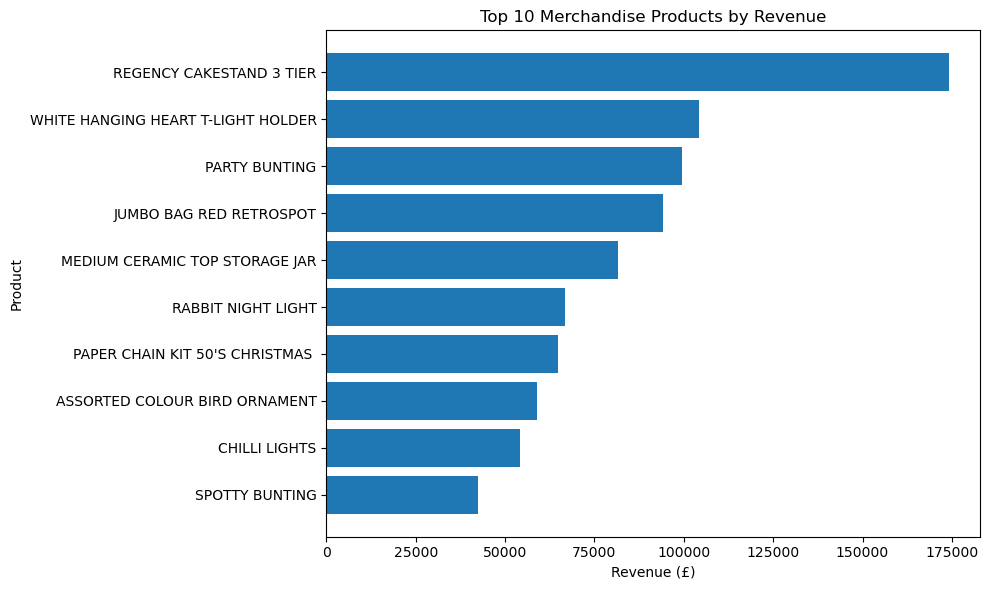

In [101]:
import matplotlib.pyplot as plt

chart_data = top_products_revenue.sort_values(
    "Revenue",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart_data["Description"],
    chart_data["Revenue"]
)

plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.title("Top 10 Merchandise Products by Revenue")

plt.tight_layout()
plt.show()

### Product Performance Insights

- REGENCY CAKESTAND 3 TIER was the highest-revenue merchandise product, generating £174,156.54 across 1,988 orders.
- WHITE HANGING HEART T-LIGHT HOLDER showed the broadest order-level demand, appearing in 2,189 orders and generating £104,284.24 in revenue.
- JUMBO BAG RED RETROSPOT performed strongly across multiple measures, generating £94,159.81 in revenue, selling 48,371 units, and appearing in 2,089 orders.
- MEDIUM CERAMIC TOP STORAGE JAR recorded the highest unit volume at 78,033 units but appeared in only 247 orders, indicating that its sales were concentrated in relatively large-quantity orders.
- Product performance differed substantially depending on whether revenue, unit volume, or order frequency was measured, highlighting the importance of using multiple product KPIs.
- A £168,469.60 PAPER CRAFT, LITTLE BIRDIE transaction involving 80,995 units was fully cancelled 12 minutes later. It was retained in the underlying sales and cancellation datasets but excluded from the merchandise performance ranking to avoid overstating product performance.

In [102]:
# Next: Step 5.6 — Geographic Performance
# Which countries generate the most revenue and orders?

country_performance = (
    sales_df
    .groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        UnitsSold=("Quantity", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

country_performance["Revenue"] = (
    country_performance["Revenue"].round(2)
)

country_performance.head(10)

,Country,Revenue,Orders,UnitsSold
36,United Kingdom,9001744.09,18019,4646906
24,Netherlands,285446.34,94,200361
10,EIRE,283140.52,288,147007
14,Germany,228678.40,457,119154
13,France,209625.37,392,112060
0,Australia,138453.81,57,83891
31,Spain,61558.56,90,27933
33,Switzerland,57067.60,54,30617
3,Belgium,41196.34,98,23237
32,Sweden,38367.83,36,36078


In [103]:
# Step 5.6B — UK Revenue Concentration

total_revenue = sales_df["Revenue"].sum()

uk_revenue = country_performance.loc[
    country_performance["Country"] == "United Kingdom",
    "Revenue"
].iloc[0]

uk_revenue_share = (uk_revenue / total_revenue) * 100

print("UK Revenue:", f"£{uk_revenue:,.2f}")
print("UK Share of Total Revenue:", f"{uk_revenue_share:.2f}%")

UK Revenue: £9,001,744.09
UK Share of Total Revenue: 84.59%


In [104]:
# calculate the non-UK market separately

non_uk_performance = (
    country_performance[
        country_performance["Country"] != "United Kingdom"
    ]
    .sort_values("Revenue", ascending=False)
)

non_uk_performance.head(10)

,Country,Revenue,Orders,UnitsSold
24,Netherlands,285446.34,94,200361
10,EIRE,283140.52,288,147007
14,Germany,228678.40,457,119154
13,France,209625.37,392,112060
0,Australia,138453.81,57,83891
31,Spain,61558.56,90,27933
33,Switzerland,57067.60,54,30617
3,Belgium,41196.34,98,23237
32,Sweden,38367.83,36,36078
20,Japan,37416.37,19,26016


In [105]:
# Step 5.6C — International Average Order Value
# Let's quantify that rather than just infer it.

non_uk_performance = non_uk_performance.copy()

non_uk_performance["AverageOrderValue"] = (
    non_uk_performance["Revenue"]
    / non_uk_performance["Orders"]
).round(2)

non_uk_performance[
    ["Country", "Revenue", "Orders", "UnitsSold", "AverageOrderValue"]
].head(10)

,Country,Revenue,Orders,UnitsSold,AverageOrderValue
24,Netherlands,285446.34,94,200361,3036.66
10,EIRE,283140.52,288,147007,983.13
14,Germany,228678.40,457,119154,500.39
13,France,209625.37,392,112060,534.76
0,Australia,138453.81,57,83891,2429.01
31,Spain,61558.56,90,27933,683.98
33,Switzerland,57067.60,54,30617,1056.81
3,Belgium,41196.34,98,23237,420.37
32,Sweden,38367.83,36,36078,1065.77
20,Japan,37416.37,19,26016,1969.28


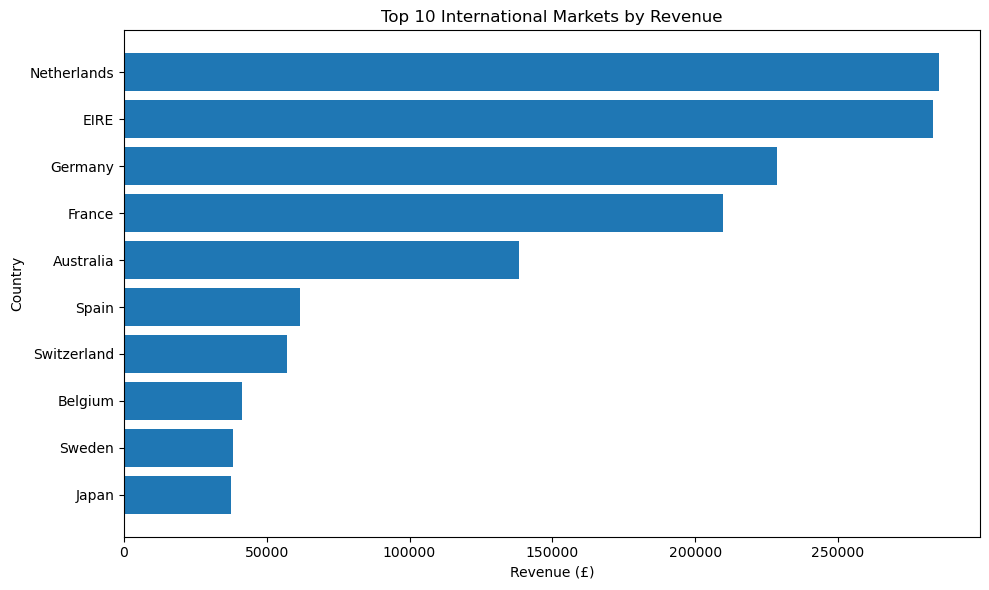

In [106]:
# Step 5.6D — Geographic Revenue Chart
# I recommend charting the top 10 international markets excluding the UK. 
# We already document that the UK accounts for 84.59%; excluding it from this particular chart makes the international differences readable.

top_international = (
    non_uk_performance
    .head(10)
    .sort_values("Revenue", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_international["Country"],
    top_international["Revenue"]
)

plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.title("Top 10 International Markets by Revenue")

plt.tight_layout()
plt.show()

### Geographic Performance Insights

- The United Kingdom was the dominant market, generating £9.00M and accounting for 84.59% of total gross positive-sales revenue.
- International revenue was led by the Netherlands (£285,446.34) and EIRE (£283,140.52), followed by Germany (£228,678.40), France (£209,625.37), and Australia (£138,453.81).
- International markets showed different purchasing patterns. The Netherlands generated £285,446.34 from only 94 orders, resulting in an average order value of £3,036.66.
- Australia also showed a high average order value of £2,429.01 across 57 orders, while Germany and France generated revenue through substantially more orders with lower average order values of £500.39 and £534.76 respectively.
- These results indicate that geographic performance should be evaluated using both revenue and purchasing behaviour, rather than revenue alone.

#### Step 5.7 — Customer Purchasing Behaviour

Now we're moving into one of the most important parts of this project. From here we use customer_df, not sales_df, because customer analysis requires a known CustomerID.

In [107]:
# let's build one row per customer

customer_summary = (
    customer_df
    .groupby("CustomerID")
    .agg(
        TotalRevenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        UnitsPurchased=("Quantity", "sum"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_summary["AverageOrderValue"] = (
    customer_summary["TotalRevenue"]
    / customer_summary["Orders"]
)

customer_summary.head()

,CustomerID,TotalRevenue,Orders,UnitsPurchased,FirstPurchase,LastPurchase,AverageOrderValue
0,12346,77183.60,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000
1,12347,4310.00,7,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286
2,12348,1797.24,4,2341,2010-12-16 19:09:00,2011-09-25 13:13:00,449.310000
3,12349,1757.55,1,631,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000
4,12350,334.40,1,197,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000


In [108]:
print("Customers:", customer_summary["CustomerID"].nunique())

print(
    "Average Revenue per Customer:",
    round(customer_summary["TotalRevenue"].mean(), 2)
)

print(
    "Median Revenue per Customer:",
    round(customer_summary["TotalRevenue"].median(), 2)
)

print(
    "Average Orders per Customer:",
    round(customer_summary["Orders"].mean(), 2)
)

print(
    "Median Orders per Customer:",
    round(customer_summary["Orders"].median(), 2)
)

Customers: 4338
Average Revenue per Customer: 2048.69
Median Revenue per Customer: 668.57
Average Orders per Customer: 4.27
Median Orders per Customer: 2.0


In [109]:
# Step 5.7B — One-Time vs Repeat Customers
# Now let's answer a very useful business question: How many customers purchased once, and how many returned for another order?

customer_summary["CustomerType"] = customer_summary["Orders"].apply(
    lambda x: "Repeat Customer" if x > 1 else "One-Time Customer"
)

customer_type_summary = (
    customer_summary["CustomerType"]
    .value_counts()
    .reset_index()
)

customer_type_summary.columns = ["CustomerType", "Customers"]

customer_type_summary["Percentage"] = (
    customer_type_summary["Customers"]
    / customer_summary["CustomerID"].nunique()
    * 100
).round(2)

customer_type_summary

,CustomerType,Customers,Percentage
0,Repeat Customer,2845,65.58
1,One-Time Customer,1493,34.42


In [110]:
# Let's compare their economic contribution

customer_type_value = (
    customer_summary
    .groupby("CustomerType")
    .agg(
        Customers=("CustomerID", "nunique"),
        TotalRevenue=("TotalRevenue", "sum"),
        AverageRevenuePerCustomer=("TotalRevenue", "mean"),
        AverageOrdersPerCustomer=("Orders", "mean")
    )
    .reset_index()
)

customer_type_value["TotalRevenue"] = (
    customer_type_value["TotalRevenue"].round(2)
)

customer_type_value["AverageRevenuePerCustomer"] = (
    customer_type_value["AverageRevenuePerCustomer"].round(2)
)

customer_type_value["AverageOrdersPerCustomer"] = (
    customer_type_value["AverageOrdersPerCustomer"].round(2)
)

customer_type_value

,CustomerType,Customers,TotalRevenue,AverageRevenuePerCustomer,AverageOrdersPerCustomer
0,One-Time Customer,1493,613989.56,411.25,1.00
1,Repeat Customer,2845,8273219.33,2907.99,5.99


In [111]:
# Step 5.7C — Revenue Contribution of Repeat Customers

customer_type_value["RevenueShare"] = (
    customer_type_value["TotalRevenue"]
    / customer_type_value["TotalRevenue"].sum()
    * 100
).round(2)

customer_type_value[
    [
        "CustomerType",
        "Customers",
        "TotalRevenue",
        "RevenueShare",
        "AverageRevenuePerCustomer",
        "AverageOrdersPerCustomer"
    ]
]

,CustomerType,Customers,TotalRevenue,RevenueShare,AverageRevenuePerCustomer,AverageOrdersPerCustomer
0,One-Time Customer,1493,613989.56,6.91,411.25,1.00
1,Repeat Customer,2845,8273219.33,93.09,2907.99,5.99


In [112]:
# let's calculate the comparison directly

repeat_avg_revenue = customer_type_value.loc[
    customer_type_value["CustomerType"] == "Repeat Customer",
    "AverageRevenuePerCustomer"
].iloc[0]

one_time_avg_revenue = customer_type_value.loc[
    customer_type_value["CustomerType"] == "One-Time Customer",
    "AverageRevenuePerCustomer"
].iloc[0]

revenue_multiple = repeat_avg_revenue / one_time_avg_revenue

print(
    "Repeat Customer Revenue Multiple:",
    round(revenue_multiple, 2),
    "x"
)

Repeat Customer Revenue Multiple: 7.07 x


In [113]:
# Step 5.7D — How Concentrated Is Customer Revenue?
# Now let's investigate whether a relatively small group of customers accounts for a large proportion of revenue.
# First, rank customers from highest to lowest revenue

customer_revenue_rank = (
    customer_summary
    .sort_values("TotalRevenue", ascending=False)
    .reset_index(drop=True)
)

customer_revenue_rank[
    ["CustomerID", "TotalRevenue", "Orders", "UnitsPurchased"]
].head(10)

,CustomerID,TotalRevenue,Orders,UnitsPurchased
0,14646,280206.02,73,196915
1,18102,259657.30,60,64124
2,17450,194390.79,46,69973
3,16446,168472.50,2,80997
4,14911,143711.17,201,80240
5,12415,124914.53,21,77374
6,14156,117210.08,55,57768
7,17511,91062.38,31,64549
8,16029,80850.84,63,40108
9,12346,77183.60,1,74215


In [114]:
# calculate how much identified-customer revenue comes from the top 10% of customers

top_10_percent_count = int(
    len(customer_revenue_rank) * 0.10
)

top_10_percent_customers = customer_revenue_rank.head(
    top_10_percent_count
)

top_10_revenue_share = (
    top_10_percent_customers["TotalRevenue"].sum()
    / customer_revenue_rank["TotalRevenue"].sum()
    * 100
)

print("Customers in Top 10%:", top_10_percent_count)

print(
    "Top 10% Revenue Share:",
    round(top_10_revenue_share, 2),
    "%"
)

Customers in Top 10%: 433
Top 10% Revenue Share: 61.41 %


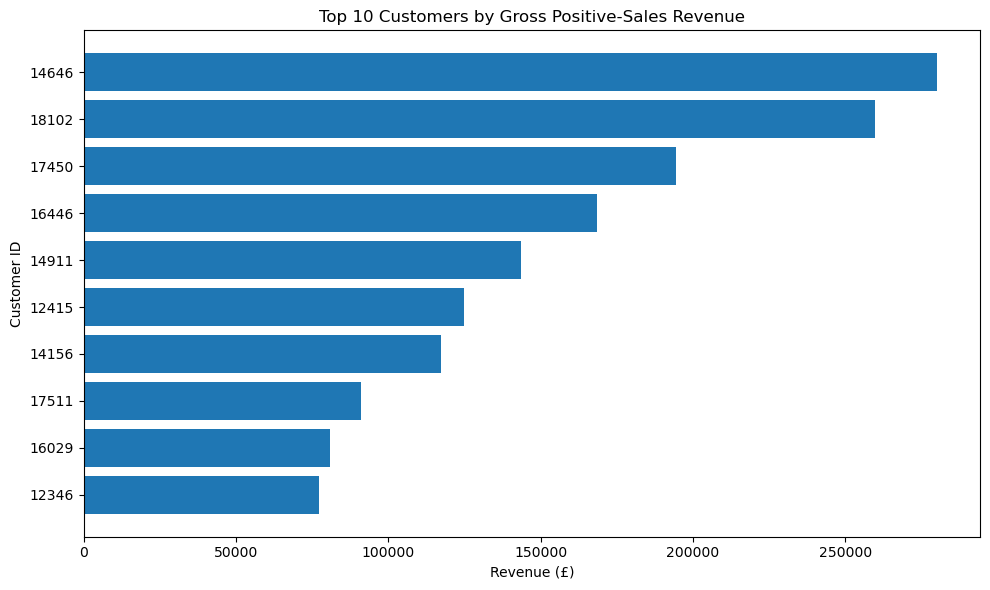

In [115]:
# Step 5.7E — Customer Revenue Concentration Chart
# Let's make one simple chart showing the top 10 customers by gross positive-sales revenue.

top_customers = (
    customer_revenue_rank
    .head(10)
    .sort_values("TotalRevenue", ascending=True)
    .copy()
)

top_customers["CustomerID"] = (
    top_customers["CustomerID"].astype(str)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers["CustomerID"],
    top_customers["TotalRevenue"]
)

plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")
plt.title("Top 10 Customers by Gross Positive-Sales Revenue")

plt.tight_layout()
plt.show()

### Customer Purchasing Behaviour Insights

- The dataset contains 4,338 identifiable customers. Average revenue per customer was £2,048.69, while median revenue was £668.57, indicating that customer spending is strongly right-skewed.
- Customers placed an average of 4.27 orders, compared with a median of 2 orders, showing that a smaller group of frequent purchasers increases the overall average.
- Repeat customers represented 65.58% of identifiable customers (2,845 customers), while 34.42% (1,493 customers) purchased only once during the observation period.
- Repeat customers generated 93.09% of identified-customer revenue and averaged £2,907.99 per customer, compared with £411.25 for one-time customers. On average, repeat customers generated 7.07 times more revenue per customer.
- Customer revenue was highly concentrated: the top 10% of identifiable customers (433 customers) generated 61.41% of identified-customer revenue.
- Customer 14646 generated the highest gross positive-sales revenue at £280,206.02, followed by customer 18102 at £259,657.30.
- Gross customer revenue should be interpreted alongside cancellations. For example, customer 16446 appears among the highest-revenue customers largely because of an £168,469.60 transaction that was subsequently fully cancelled.

#### Step 5.8 Cancellation Analysis

We've kept cancellations separate specifically for this stage.

Before calculating cancellation rates, we need to inspect the cancellation dataset more carefully. Earlier we calculated CancellationValue, but now let's verify whether every cancellation has a positive UnitPrice.

In [116]:
print(
    "Cancellation Rows:",
    len(cancellations_df)
)

print(
    "Positive UnitPrice:",
    (cancellations_df["UnitPrice"] > 0).sum()
)

print(
    "Zero UnitPrice:",
    (cancellations_df["UnitPrice"] == 0).sum()
)

print(
    "Negative UnitPrice:",
    (cancellations_df["UnitPrice"] < 0).sum()
)

print(
    "Missing UnitPrice:",
    cancellations_df["UnitPrice"].isna().sum()
)

Cancellation Rows: 9251
Positive UnitPrice: 9251
Zero UnitPrice: 0
Negative UnitPrice: 0
Missing UnitPrice: 0


In [117]:
# Step 5.8B — Overall Cancellation Metrics
# Now let's calculate the headline cancellation numbers

total_cancellation_value = cancellations_df["CancellationValue"].sum()

cancelled_units = cancellations_df["Quantity"].abs().sum()

cancelled_invoices = cancellations_df["InvoiceNo"].nunique()

customers_with_cancellations = (
    cancellations_df["CustomerID"].nunique()
)

print(
    "Total Cancellation Value:",
    f"£{total_cancellation_value:,.2f}"
)

print(
    "Cancelled Units:",
    f"{cancelled_units:,}"
)

print(
    "Cancellation Invoices:",
    f"{cancelled_invoices:,}"
)

print(
    "Customers with Cancellations:",
    f"{customers_with_cancellations:,}"
)

Total Cancellation Value: £893,979.73
Cancelled Units: 275,560
Cancellation Invoices: 3,836
Customers with Cancellations: 1,589


In [118]:
# Step 5.8C — Customers Involved in Cancellations
# Let's now quantify how widespread cancellation activity is among identifiable customers.

total_identifiable_customers = customer_df["CustomerID"].nunique()

customers_with_cancellations = (
    cancellations_df["CustomerID"]
    .dropna()
    .nunique()
)

cancellation_customer_share = (
    customers_with_cancellations
    / total_identifiable_customers
    * 100
)

print(
    "Total Identifiable Customers:",
    f"{total_identifiable_customers:,}"
)

print(
    "Customers with Cancellations:",
    f"{customers_with_cancellations:,}"
)

print(
    "Share of Customers with Cancellations:",
    f"{cancellation_customer_share:.2f}%"
)

Total Identifiable Customers: 4,338
Customers with Cancellations: 1,589
Share of Customers with Cancellations: 36.63%


In [119]:
# Step 5.8D — Products With the Highest Cancellation Value
# Now let's identify where the monetary value of cancellations is concentrated.

product_cancellations = (
    cancellations_df
    .groupby(["StockCode", "Description"])
    .agg(
        CancellationValue=("CancellationValue", "sum"),
        CancelledUnits=("Quantity", lambda x: x.abs().sum()),
        CancellationInvoices=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values("CancellationValue", ascending=False)
)

product_cancellations["CancellationValue"] = (
    product_cancellations["CancellationValue"].round(2)
)

product_cancellations.head(10)

,StockCode,Description,CancellationValue,CancelledUnits,CancellationInvoices
1966,AMAZONFEE,AMAZON FEE,235281.59,32,32
1512,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
1972,M,Manual,146784.46,4066,223
1253,23166,MEDIUM CERAMIC TOP STORAGE JAR,77479.64,74494,10
1973,POST,POSTAGE,11871.24,147,124
706,22423,REGENCY CAKESTAND 3 TIER,9697.05,855,180
1969,CRUK,CRUK Commission,7933.43,16,16
1967,BANK CHARGES,Bank Charges,7340.64,25,25
1893,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6624.30,2578,42
116,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,6591.42,3150,3


#### Step 5.8E — Separate Merchandise Cancellations

We shouldn't delete the fee/accounting cancellations from cancellations_df because they're part of the transactional record. Instead, just as we did for product sales, we'll create a merchandise-specific cancellation dataset.

In [120]:
# First, let's inspect the unusual CRUK code because it didn't appear in our positive-sales special-code table.

cancellations_df[
    cancellations_df["StockCode"].astype(str) == "CRUK"
][
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID",
        "CancellationValue"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,CancellationValue
317508,C564763,CRUK,CRUK Commission,-1,1.60,14096.0,1.60
324023,C565382,CRUK,CRUK Commission,-1,13.01,14096.0,13.01
333779,C566216,CRUK,CRUK Commission,-1,15.96,14096.0,15.96
338848,C566565,CRUK,CRUK Commission,-1,52.24,14096.0,52.24
351003,C567655,CRUK,CRUK Commission,-1,608.66,14096.0,608.66
361603,C568345,CRUK,CRUK Commission,-1,447.56,14096.0,447.56
372785,C569245,CRUK,CRUK Commission,-1,361.59,14096.0,361.59
390002,C570487,CRUK,CRUK Commission,-1,411.92,14096.0,411.92
401767,C571440,CRUK,CRUK Commission,-1,495.98,14096.0,495.98
416464,C572551,CRUK,CRUK Commission,-1,425.14,14096.0,425.14


In [121]:
cancellations_df[
    cancellations_df["StockCode"].astype(str) == "AMAZONFEE"
][
    [
        "InvoiceNo",
        "Description",
        "Quantity",
        "UnitPrice",
        "CancellationValue"
    ]
].head(10)

,InvoiceNo,Description,Quantity,UnitPrice,CancellationValue
14514,C537600,AMAZON FEE,-1,1.00,1.00
15016,C537630,AMAZON FEE,-1,13541.33,13541.33
16232,C537644,AMAZON FEE,-1,13474.79,13474.79
16313,C537647,AMAZON FEE,-1,5519.25,5519.25
16356,C537651,AMAZON FEE,-1,13541.33,13541.33
16357,C537652,AMAZON FEE,-1,6706.71,6706.71
43702,C540117,AMAZON FEE,-1,16888.02,16888.02
43703,C540118,AMAZON FEE,-1,16453.71,16453.71
96844,C544587,AMAZON FEE,-1,5575.28,5575.28
96845,C544589,AMAZON FEE,-1,5258.77,5258.77


In [122]:
# Step 5.8F — Create Merchandise Cancellation Dataset
# We'll use the same exclusions from our product analysis, plus CRUK.

non_product_cancel_codes = [
    "DOT",
    "POST",
    "M",
    "m",
    "AMAZONFEE",
    "B",
    "BANK CHARGES",
    "C2",
    "S",
    "CRUK",
    "gift_0001_10",
    "gift_0001_20",
    "gift_0001_30",
    "gift_0001_40",
    "gift_0001_50"
]

product_cancellations_df = cancellations_df[
    ~cancellations_df["StockCode"]
    .astype(str)
    .isin(non_product_cancel_codes)
].copy()

product_cancellations_df.shape

(8745, 9)

In [123]:
# Then rebuild the cancellation ranking

product_cancellation_summary = (
    product_cancellations_df
    .groupby(["StockCode", "Description"])
    .agg(
        CancellationValue=("CancellationValue", "sum"),
        CancelledUnits=("Quantity", lambda x: x.abs().sum()),
        CancellationInvoices=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values("CancellationValue", ascending=False)
)

product_cancellation_summary["CancellationValue"] = (
    product_cancellation_summary["CancellationValue"].round(2)
)

product_cancellation_summary.head(10)

,StockCode,Description,CancellationValue,CancelledUnits,CancellationInvoices
1512,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
1253,23166,MEDIUM CERAMIC TOP STORAGE JAR,77479.64,74494,10
706,22423,REGENCY CAKESTAND 3 TIER,9697.05,855,180
1893,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6624.30,2578,42
116,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,6591.42,3150,3
1966,D,Discount,5696.22,1194,65
1213,23113,PANTRY CHOPPING BOARD,4803.06,946,6
1550,48185,DOORMAT FAIRY CAKE,4554.90,674,3
141,21175,GIN + TONIC DIET METAL SIGN,3775.33,2030,7
1741,47566B,TEA TIME PARTY BUNTING,3692.95,1424,7


In [124]:
# Step 5.8F — Final Merchandise Cancellation Ranking
# Add "D" to the exclusions:

non_product_cancel_codes = [
    "DOT",
    "POST",
    "M",
    "m",
    "AMAZONFEE",
    "B",
    "BANK CHARGES",
    "C2",
    "S",
    "CRUK",
    "D",
    "gift_0001_10",
    "gift_0001_20",
    "gift_0001_30",
    "gift_0001_40",
    "gift_0001_50"
]

product_cancellations_df = cancellations_df[
    ~cancellations_df["StockCode"]
    .astype(str)
    .isin(non_product_cancel_codes)
].copy()

In [125]:
product_cancellation_summary = (
    product_cancellations_df
    .groupby(["StockCode", "Description"])
    .agg(
        CancellationValue=("CancellationValue", "sum"),
        CancelledUnits=("Quantity", lambda x: x.abs().sum()),
        CancellationInvoices=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values("CancellationValue", ascending=False)
)

product_cancellation_summary["CancellationValue"] = (
    product_cancellation_summary["CancellationValue"].round(2)
)

product_cancellation_summary.head(10)

,StockCode,Description,CancellationValue,CancelledUnits,CancellationInvoices
1512,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
1253,23166,MEDIUM CERAMIC TOP STORAGE JAR,77479.64,74494,10
706,22423,REGENCY CAKESTAND 3 TIER,9697.05,855,180
1893,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6624.30,2578,42
116,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,6591.42,3150,3
1213,23113,PANTRY CHOPPING BOARD,4803.06,946,6
1550,48185,DOORMAT FAIRY CAKE,4554.90,674,3
141,21175,GIN + TONIC DIET METAL SIGN,3775.33,2030,7
1741,47566B,TEA TIME PARTY BUNTING,3692.95,1424,7
607,22273,FELTCRAFT DOLL MOLLY,3512.65,1447,5


In [126]:
# Step 5.8G — Compare Product Sales With Cancellations
# Now we want to answer a stronger business question:
# Which products have high cancellations relative to their positive sales?
# We'll merge our positive merchandise sales with merchandise cancellations.

product_sales_summary = (
    product_sales_df
    .groupby(["StockCode", "Description"])
    .agg(
        SalesRevenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        SalesOrders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

product_cancel_comparison = product_sales_summary.merge(
    product_cancellation_summary,
    on=["StockCode", "Description"],
    how="left"
)

product_cancel_comparison[
    ["CancellationValue", "CancelledUnits", "CancellationInvoices"]
] = (
    product_cancel_comparison[
        ["CancellationValue", "CancelledUnits", "CancellationInvoices"]
    ].fillna(0)
)

In [127]:
# Now calculate two useful ratios

product_cancel_comparison["CancellationValuePctOfGrossSales"] = (
    product_cancel_comparison["CancellationValue"]
    / product_cancel_comparison["SalesRevenue"]
    * 100
)

product_cancel_comparison["CancelledUnitsPctOfGrossUnits"] = (
    product_cancel_comparison["CancelledUnits"]
    / product_cancel_comparison["UnitsSold"]
    * 100
)

In [128]:
# Before ranking anything, let's inspect our known unusual products

product_cancel_comparison[
    product_cancel_comparison["StockCode"]
    .astype(str)
    .isin(["23843", "23166", "22423", "85123A"])
][
    [
        "StockCode",
        "Description",
        "SalesRevenue",
        "CancellationValue",
        "CancellationValuePctOfGrossSales",
        "UnitsSold",
        "CancelledUnits",
        "CancelledUnitsPctOfGrossUnits",
        "SalesOrders",
        "CancellationInvoices"
    ]
].round(2)

,StockCode,Description,SalesRevenue,CancellationValue,CancellationValuePctOfGrossSales,UnitsSold,CancelledUnits,CancelledUnitsPctOfGrossUnits,SalesOrders,CancellationInvoices
1262,22423,REGENCY CAKESTAND 3 TIER,174156.54,9697.05,5.57,13851,855.0,6.17,1988,180.0
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,77479.64,94.83,78033,74494.0,95.46,247,10.0
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,168469.60,100.00,80995,80995.0,100.00,1,1.0
3772,85123A,CREAM HANGING HEART T-LIGHT HOLDER,178.51,0.00,0.00,61,0.0,0.00,9,0.0
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,6624.30,6.35,37580,2578.0,6.86,2189,42.0


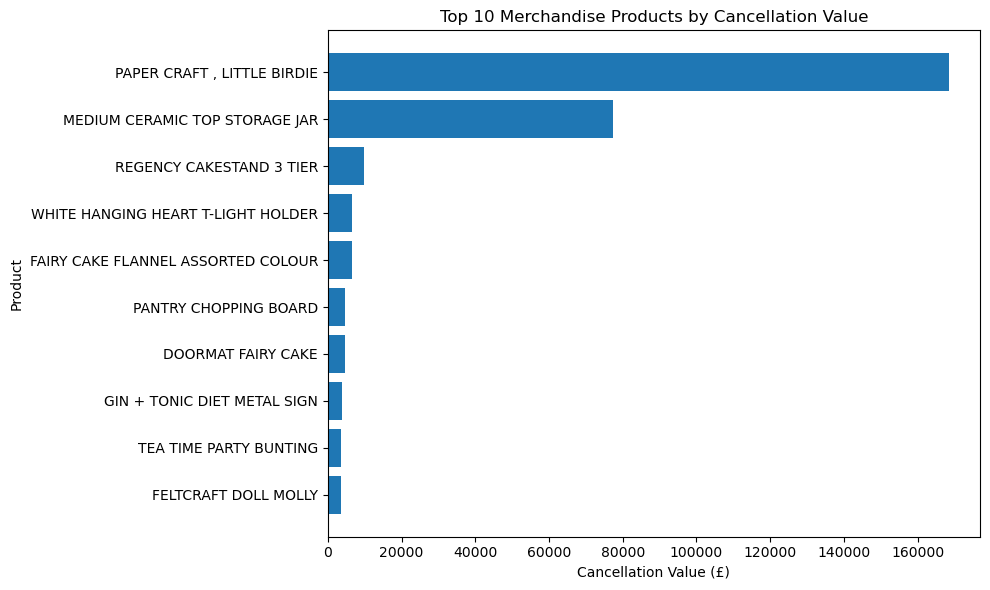

In [129]:
# Step 5.8H — Final Cancellation Chart
# For the chart, we'll show the top merchandise products by cancellation value.

import matplotlib.pyplot as plt

top_cancelled_products = (
    product_cancellation_summary
    .head(10)
    .sort_values("CancellationValue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_cancelled_products["Description"],
    top_cancelled_products["CancellationValue"]
)

plt.xlabel("Cancellation Value (£)")
plt.ylabel("Product")
plt.title("Top 10 Merchandise Products by Cancellation Value")

plt.tight_layout()
plt.show()

### Cancellation Analysis Insights

- The dataset contains 3,836 distinct cancellation invoices representing 275,560 cancelled units and £893,979.73 in cancellation value.
- 1,589 identifiable customers were associated with at least one cancellation, equivalent to 36.63% of the 4,338 customers appearing in positive-sales transactions during the observation period.
- Cancellation records include merchandise as well as operational and financial entries such as Amazon fees, postage, commissions, bank charges, discounts, and manual adjustments. These non-product codes were excluded from the merchandise cancellation ranking.
- PAPER CRAFT, LITTLE BIRDIE recorded the highest merchandise cancellation value at £168,469.60. The entire 80,995-unit positive transaction was cancelled 12 minutes later, representing a complete reversal.
- MEDIUM CERAMIC TOP STORAGE JAR recorded £77,479.64 in cancellation value across 74,494 units. This represented 94.83% of its gross positive-sales value and 95.46% of its positive-sales unit volume.
- REGENCY CAKESTAND 3 TIER showed a different cancellation pattern, with £9,697.05 in cancellation value across 180 cancellation invoices. Its cancellation value was equivalent to 5.57% of gross positive-sales value.
- WHITE HANGING HEART T-LIGHT HOLDER recorded £6,624.30 in cancellation value, equivalent to 6.35% of its gross positive-sales value.
- Cancellation-value percentages are comparisons with gross positive-sales activity and should not be interpreted as formal product return rates because cancellation records do not explicitly identify the original invoice being reversed.

## 5.9 Final Business Insights

The exploratory analysis identified several important patterns in the retailer's sales performance, customer behaviour, product demand, geographic concentration, and cancellation activity.

### Sales Performance

- The business generated £10.64M in gross positive-sales revenue from 19,960 orders and 5.57M units sold across 3,922 products.
- Average order value was £533.17.
- Revenue increased substantially during the later months of 2011. September generated approximately £1.06M, October £1.15M, and November reached the dataset's highest complete-month revenue of £1.50M.
- November also recorded the highest complete-month order volume at 2,769 orders.
- Average order value remained relatively stable during the September–November growth period, indicating that the revenue increase was primarily associated with higher order activity rather than unusually large orders.
- December 2011 contains data only through 9 December and therefore should not be directly compared with complete months.

### Product Performance

- REGENCY CAKESTAND 3 TIER was the highest-revenue merchandise product, generating £174,156.54 across 1,988 orders.
- WHITE HANGING HEART T-LIGHT HOLDER showed particularly broad demand, appearing in 2,189 orders and generating £104,284.24.
- JUMBO BAG RED RETROSPOT performed strongly across revenue, unit volume, and order frequency, generating £94,159.81 from 48,371 units across 2,089 orders.
- MEDIUM CERAMIC TOP STORAGE JAR recorded the highest merchandise unit volume at 78,033 units but appeared in only 247 orders, indicating that its positive sales were concentrated in relatively large-quantity orders.
- Product performance varies considerably depending on whether revenue, units sold, or order frequency is measured, so multiple KPIs are required when evaluating product performance.

### Geographic Performance

- The United Kingdom dominated the business, generating approximately £9.00M and accounting for 84.59% of gross positive-sales revenue.
- Among international markets, the Netherlands (£285,446.34) and EIRE (£283,140.52) generated the highest revenue, followed by Germany and France.
- International purchasing patterns varied considerably. The Netherlands generated an average order value of £3,036.66 from only 94 orders, while Australia averaged £2,429.01 across 57 orders.
- Germany and France generated revenue through substantially more orders but at lower average order values, demonstrating that market performance should be assessed using both revenue and purchasing behaviour.

### Customer Behaviour

- The dataset contains 4,338 identifiable customers.
- Average revenue per customer was £2,048.69 compared with a median of £668.57, showing that customer spending was strongly right-skewed.
- Repeat customers represented 65.58% of identifiable customers and generated 93.09% of identified-customer gross positive-sales revenue.
- Repeat customers generated an average of £2,907.99 per customer compared with £411.25 for one-time customers — approximately 7.07 times more.
- Customer revenue was highly concentrated: the top 10% of identifiable customers generated 61.41% of identified-customer revenue.
- Customer 14646 recorded the highest gross positive-sales revenue at £280,206.02, followed by customer 18102 at £259,657.30.
- Gross customer revenue should be interpreted alongside cancellations because large subsequently cancelled transactions can materially affect customer rankings.

### Cancellation Behaviour

- The dataset contains 3,836 distinct cancellation invoices representing 275,560 cancelled units and £893,979.73 in cancellation value.
- 1,589 identifiable customers were associated with at least one cancellation during the observation period.
- PAPER CRAFT, LITTLE BIRDIE recorded a £168,469.60 positive transaction involving 80,995 units that was completely cancelled 12 minutes later.
- MEDIUM CERAMIC TOP STORAGE JAR recorded £77,479.64 in cancellation value, equivalent to 94.83% of its gross positive-sales value and 95.46% of its positive-sales unit volume.
- REGENCY CAKESTAND 3 TIER displayed a different pattern, with £9,697.05 in cancellation value spread across 180 cancellation invoices.
- Cancellation records also contained fees, postage, commissions, discounts, and other operational or financial adjustments. These were retained in the underlying cancellation dataset but excluded when ranking merchandise cancellations.
- Cancellation-value comparisons should not be interpreted as formal return rates because the dataset does not explicitly link each cancellation record to its original sales invoice.

### Business Implications

The analysis suggests that revenue growth was strongly associated with increased order activity, particularly during the later months of 2011. Repeat customers contributed disproportionately to identified-customer revenue, highlighting the commercial importance of repeat purchasing.

The business is highly concentrated geographically in the United Kingdom and economically among a relatively small group of high-value customers. International markets nevertheless show distinct purchasing patterns that may warrant market-specific analysis.

Product performance should be evaluated using revenue, volume, order frequency, and cancellation behaviour together. Several unusually large transactions and cancellations demonstrate why transaction-level anomalies must be investigated before drawing conclusions from aggregate KPIs.

In [130]:
sales_df.to_csv(
    "../data/ecommerce_sales_clean.csv",
    index=False
)

cancellations_df.to_csv(
    "../data/ecommerce_cancellations_clean.csv",
    index=False
)

customer_df.to_csv(
    "../data/ecommerce_customer_sales_clean.csv",
    index=False
)

print("CSV files exported successfully.")

CSV files exported successfully.


In [131]:
sales_df["StockCode"].nunique()

3922

In [132]:
sales_df["Description"].nunique()

4026

In [133]:
sales_df["StockCode"].astype(str).str.strip().str.upper().nunique()

3812